In [8]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt


# Загружаем изображение и преобразуем его в чёрно-белое
img = Image.open("image-3.png").convert('L')
img = img.resize((28, 28))

pixels = np.array(img) / 255.0
inputs = pixels.flatten()

np.random.seed(42)

# Создайте переменные weights и bias здесь
weights = np.random.randn(len(inputs))   # Ваш код здесь
bias = np.random.randn()      # Ваш код здесь


print("Количество входов:", len(inputs))
print("Форма weights:", weights.shape)
print("Пример первых 5 весов:", weights[:5])
print("Bias:", bias) 

Количество входов: 784
Форма weights: (784,)
Пример первых 5 весов: [ 0.49671415 -0.1382643   0.64768854  1.52302986 -0.23415337]
Bias: 0.5597904479310398


In [25]:
img = Image.open("image-3.png").convert('L').resize((28, 28))
pixels = np.array(img) / 255.0
inputs = pixels.flatten()

np.random.seed(42)
weights = np.random.randn(len(inputs))
bias = np.random.randn()

# Напишите код функции ReLU - верните «обрезанное» значение — минимум 0, максимум x.
# Ваш код здесь
def relu(x):
    return np.maximum(0,x)

# Допишите код функции нейрона.
def neuron(inputs, weights, bias):    
    # Вычислите total = сумма + bias
    total = np.dot(inputs, weights) + bias
    # Примените ReLU
    output = relu(total)
    return output

output = neuron(inputs, weights, bias)
print("Выход нейрона:", output) 

Выход нейрона: 0.0


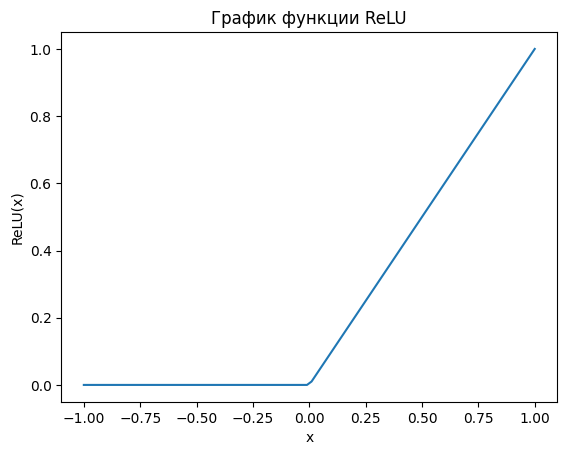

In [26]:
def relu(x):
    return np.maximum(0,x)

x = np.linspace(-1, 1, 100)
y = relu(x)  # применяем вашу функцию

plt.plot(x, y)
plt.title("График функции ReLU")
plt.xlabel("x")
plt.ylabel("ReLU(x)")
plt.show()

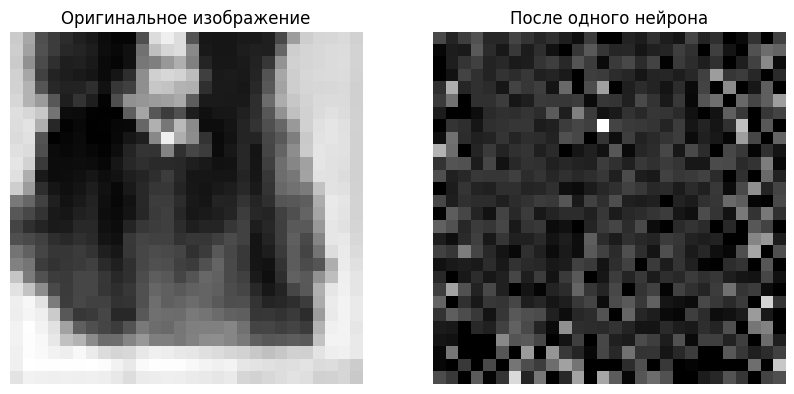

In [30]:
np.random.seed(42) 
img = Image.open("data/image-3.png").convert('L')
img = img.resize((28, 28))
pixels = np.array(img) / 255.0
weights = np.random.randn(28 * 28)
bias = np.random.randn()

def relu(x): 
    return np.maximum(0, x)

# Допишите функцию pixelwise_neuron: которая берёт pixels, превращает в плоский вектор, затем поэлементно умножает 
# на weights и прибавляет bias, применяет вашу функцию relu ко всем элементам, восстанавливает форму (28×28) и возвращает результат.
def pixelwise_neuron(pixels, weights, bias):
    flat = pixels.flatten()
    activated = relu(flat * weights + bias)
    return activated.reshape(pixels.shape)


# Примените только что написанную функцию к изображению
processed = pixelwise_neuron(pixels, weights, bias)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(pixels, cmap='gray')
axs[0].set_title('Оригинальное изображение')
axs[0].axis('off')

axs[1].imshow(processed, cmap='gray')
axs[1].set_title('После одного нейрона')
axs[1].axis('off')

plt.show() 

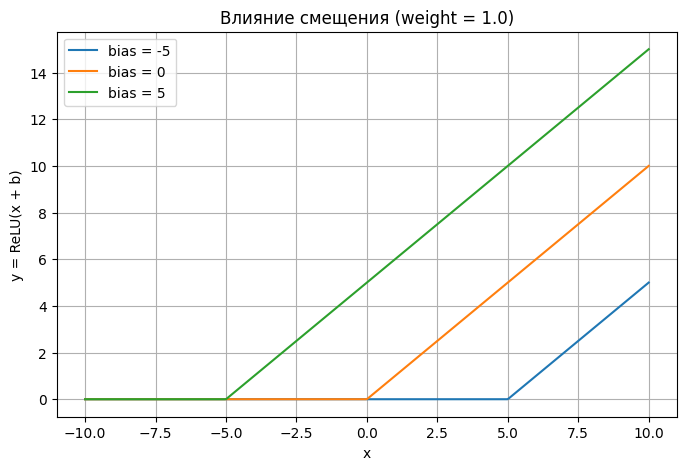

In [35]:
import numpy as np
import matplotlib.pyplot as plt

def relu(x):
    return np.maximum(0,x)
    # Допишите код как реализацию функции ReLU

def neuron(x, weight, bias):    
    return relu(x * weight + bias)
    # Допишите код как реализацию нейрона с весами и смещением

x = np.linspace(-10, 10, 400)
weight = 1.0
biases = [-5, 0, 5]

plt.figure(figsize=(8, 5))
for b in biases:
    y = neuron(x, weight, b)
    plt.plot(x, y, label=f"bias = {b}")

plt.title("Влияние смещения (weight = 1.0)")
plt.xlabel("x")
plt.ylabel("y = ReLU(x + b)")
plt.legend()
plt.grid(True)
plt.show() 

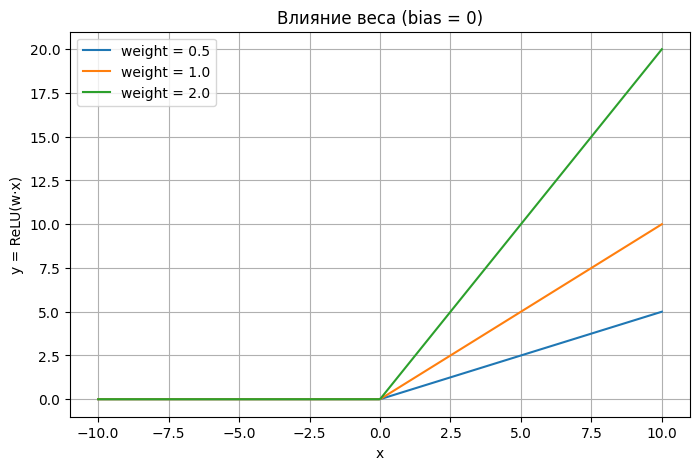

In [36]:
# диапазон входов
x = np.linspace(-10, 10, 400)
bias = 0
weights = [0.5, 1.0, 2.0]

plt.figure(figsize=(8, 5))
for w in weights:
    y = neuron(x, w, bias)
    plt.plot(x, y, label=f"weight = {w}")

plt.title("Влияние веса (bias = 0)")
plt.xlabel("x")
plt.ylabel("y = ReLU(w·x)")
plt.legend()
plt.grid(True)
plt.show() 

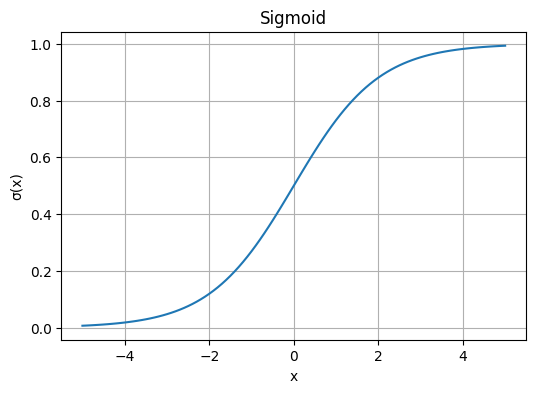

In [37]:
import math

def sigmoid(x: float) -> float:
    return 1 / (1 + math.exp(-x))

x_vals = [i * 0.1 for i in range(-50, 51)] # Генерируем значения от -5 до 5 с шагом 0.1
y_vals = [sigmoid(x) for x in x_vals] # Применяем функцию sigmoid к каждому значению

plt.figure(figsize=(6,4))
plt.plot(x_vals, y_vals)
plt.title("Sigmoid")
plt.xlabel("x")
plt.ylabel("σ(x)")
plt.grid(True)
plt.show() 

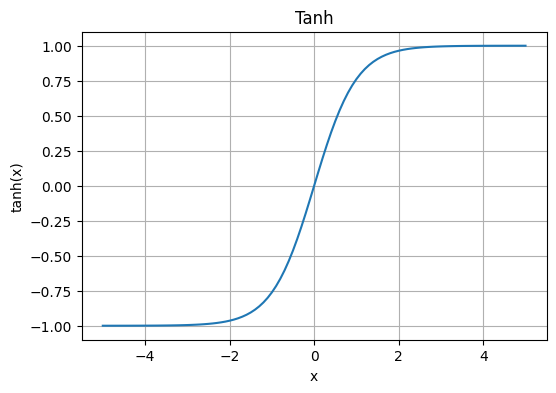

In [38]:
def tanh(x: float) -> float:
    return math.tanh(x)

x_vals = [i * 0.1 for i in range(-50, 51)]
y_vals = [tanh(x) for x in x_vals]
plt.figure(figsize=(6,4))
plt.plot(x_vals, y_vals)
plt.title("Tanh")
plt.xlabel("x")
plt.ylabel("tanh(x)")
plt.grid(True)
plt.show() 

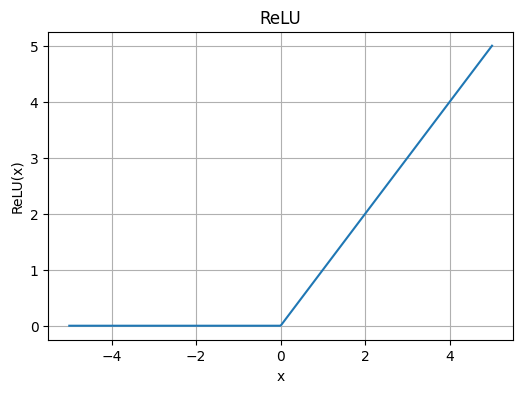

In [39]:
def relu(x):
    return np.maximum(0, x)

x_vals = np.linspace(-5, 5, 400)
y_vals = relu(x_vals)
plt.figure(figsize=(6,4))
plt.plot(x_vals, y_vals)
plt.title("ReLU")
plt.xlabel("x")
plt.ylabel("ReLU(x)")
plt.grid(True)
plt.show() 

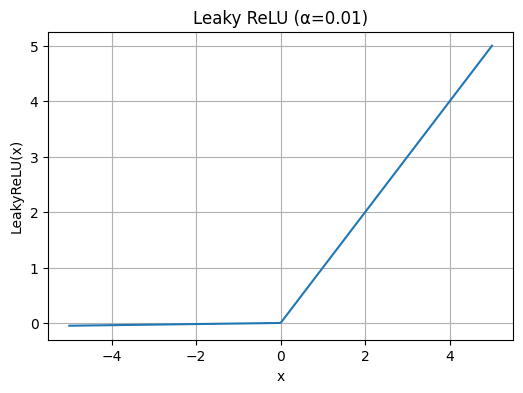

In [40]:
def leaky_relu(x, alpha=0.01):
    return np.where(x >= 0, x, alpha * x)

x_vals = np.linspace(-5, 5, 400)
y_vals = leaky_relu(x_vals)
plt.figure(figsize=(6,4))
plt.plot(x_vals, y_vals)
plt.title("Leaky ReLU (α=0.01)")
plt.xlabel("x")
plt.ylabel("LeakyReLU(x)")
plt.grid(True)
plt.show() 

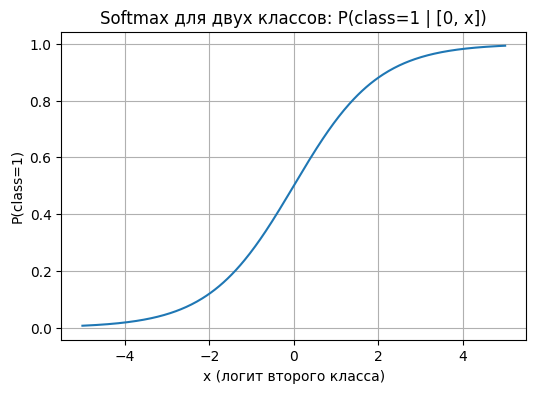

In [41]:
def softmax(z):
    # 1) для стабильности вычитаем максимум
    e_z = np.exp(z - np.max(z))
    # 2) нормируем экспоненты, чтобы сумма = 1
    return e_z / e_z.sum()

# диапазон значений второго логита
x_vals = np.linspace(-5, 5, 400)
# для каждого x считаем только P(class=1) в Softmax([0, x])
p1 = [softmax([0, x])[1] for x in x_vals]

plt.figure(figsize=(6,4))
plt.plot(x_vals, p1)
plt.title("Softmax для двух классов: P(class=1 | [0, x])")
plt.xlabel("x (логит второго класса)")
plt.ylabel("P(class=1)")
plt.grid(True)
plt.show() 

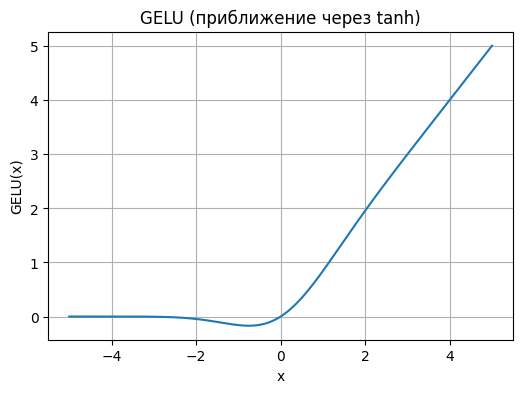

In [42]:
def gelu(x: np.ndarray) -> np.ndarray:
    # Приближение через tanh
    return 0.5 * x * (1 + np.tanh(np.sqrt(2/np.pi)*(x + 0.044715 * x**3)))

# Диапазон для визуализации
x_vals = np.linspace(-5, 5, 400)
y_vals = gelu(x_vals)

plt.figure(figsize=(6,4))
plt.plot(x_vals, y_vals)
plt.title("GELU (приближение через tanh)")
plt.xlabel("x")
plt.ylabel("GELU(x)")
plt.grid(True)
plt.show()

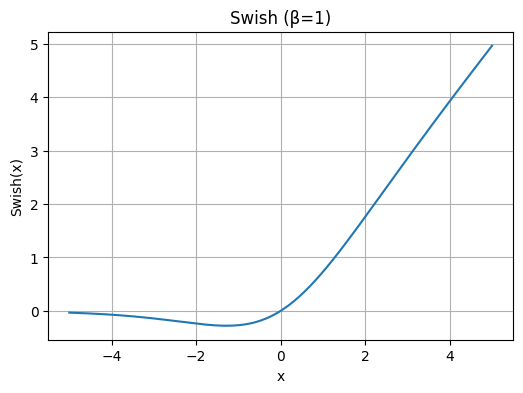

In [43]:
def sigmoid(x: np.ndarray) -> np.ndarray:
    return 1 / (1 + np.exp(-x))

def swish(x: np.ndarray, beta: float = 1.0) -> np.ndarray:
    return x * sigmoid(beta * x)

# Диапазон для визуализации
x_vals = np.linspace(-5, 5, 400)
y_vals = swish(x_vals)

plt.figure(figsize=(6,4))
plt.plot(x_vals, y_vals)
plt.title("Swish (β=1)")
plt.xlabel("x")
plt.ylabel("Swish(x)")
plt.grid(True)
plt.show() 

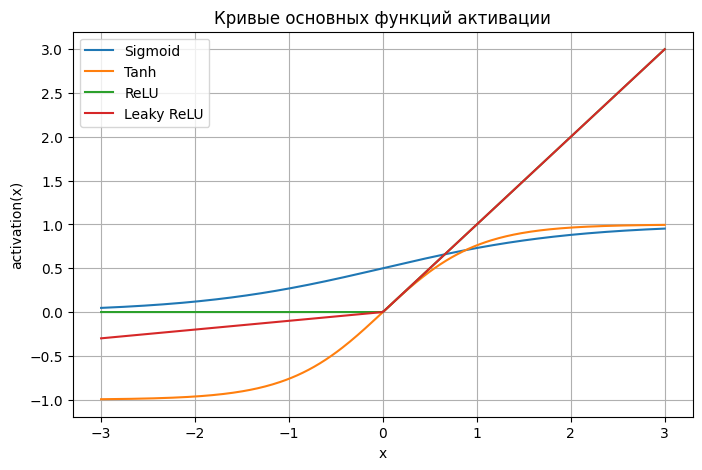

In [47]:
# 1) Входные данные
x = np.linspace(-3, 3, 300)

# 2) Реализация функций активации

def sigmoid(x: float) -> float:
    return 1 / (1 + np.exp(-x))

def tanh_act(x: float) -> float:
    return np.tanh(x)

def relu(x):
    return np.maximum(0, x)

def leaky_relu(x, alpha=0.1):
    return np.where(x >= 0, x, x * alpha)

# 3) Вычисление значений (раскомментируйте после реализации функций)
y_sig = sigmoid(x)
y_tanh = tanh_act(x)
y_relu = relu(x)
y_leaky = leaky_relu(x)

# 4) Визуализация (оставьте без изменений)
plt.figure(figsize=(8, 5))
plt.plot(x, y_sig, label='Sigmoid')
plt.plot(x, y_tanh, label='Tanh')
plt.plot(x, y_relu, label='ReLU')
plt.plot(x, y_leaky, label='Leaky ReLU')
plt.title('Кривые основных функций активации')
plt.xlabel('x')
plt.ylabel('activation(x)')
plt.legend()
plt.grid(True)
plt.show() 

In [ ]:
import numpy as np

class SampleMLP:
    def __init__(self, layer_sizes, activation='sigmoid'):
        self.layer_sizes = layer_sizes
        self.activation = activation
        self.W = []
        self.b = []
        for i in range(len(layer_sizes) - 1):
            in_dim = layer_sizes[i]
            out_dim = layer_sizes[i + 1]
            # Инициализация весов небольшой случайной матрицей
            weight_matrix = np.random.randn(in_dim, out_dim) * 0.1
            # Инициализация смещения нулями
            bias_vector = np.zeros((1, out_dim))
            self.W.append(weight_matrix)
            self.b.append(bias_vector) 